<h1><center>Modelling and Engineering of Nanoscale Materials <br> Exercises session 6: Enhanced sampling - 2025 </center></h1>
<center>massimo.bocus@ugent.be,  arnout.maet@ugent.be, thomas.nicholas@ugent.be</center>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ase.units import *
from ase.io import read
from ase.visualize import view

from pyiron import Project, ase_to_pyiron

%matplotlib inline

<div class="alert alert-block alert-warning">
<b>Educational Objectives</b> <br> 
    
1. Understand the need for enhanced sampling simulations <br>
2. Use enhanced sampling methods to compute free energy profiles <br>
3. Explore the effect of selecting different collective variables    
</div>

## Introduction

In this exercise session, we will learn about enhanced sampling methods. The goal of enhanced sampling is to artificially increase the time spent exploring high-energy regions of the potential energy surface and, thanks to that, deriving free energy profiles that describe rare events.

Due to the relatively large cost of the simulations, we have already performed them for you and made the output trajectory and data available in the input directory. Therefore, we will not need pyiron for this session. For your interest, all MDs related to ammonia have been performed on the gas-phase molecules using the semiempirical PM6 method to evaluate the potential energy surface. We used a Nosé-Hoover thermostat with 3 beads for temperature control, a time step of 0.5 fs and saved a structure every 2 steps (hence every fs). Aside from the trajectory in xyz format, you can also access additional quantities (such as temperature or the conserved quantity of the thermostat) by loading (e.g., with `numpy.loadtxt`), the out.ener files contained in each simulation directory.

<b> Begin by copying `input/session6_input` in any subdirectory of your personal folder. </b> 

In [2]:
pr = Project("session6")

## Exercise 1: Why do we need enhanced sampling?

<div class="alert alert-block alert-warning">
<b>In short:</b> <br>
    1. Examine three equilibrium MD simulations of ammonia (NH<sub>3</sub>) conducted at different temperatures. <br>
    2. Devise a collective variable to compute the free energy of the pyramidal inversion.
</div>

The simulation results are available in `session6/nh3/md`, one subdirectory per temperature is present. The trajectory xyz is called `traj.xyz` while additional information about the MD (temperature, energy, etc.) is listed in `out.ener`.

Ammonia can undergo a so-called pyramidal inversion, also know as nitrogen inversion, where the N atom passes through the 3 H atoms and the molecule flips. While, obviously, the initial and final state of this event are indistinguishable, the inversion can be explicitly observed if the N atom carries 3 different groups as, in that case, the two states are non-superimposable mirror images of each other (also know as enantiomers, just like your hands).

<figure>
<center><img src="https://upload.wikimedia.org/wikipedia/commons/2/2d/Nitrogen-inversion-3D-balls.png" width="600"></center>
<center><figcaption>Figure 1: Illustration of the nitrogen inversion.</figcaption></center>
</figure>

<div class="alert alert-block alert-success">
<b>Answer the following questions:</b> <br>   
<ol type='a'>
<li> Think about a collective variable that would be ideal to describe the pyramidal inversion. Make sure your collective variable can distinguish between the two states! </li>
<br>
<li> Load and analyze the regular MD simulations of ammonia performed at 300, 3000, and 6000 K. Compute your collective variable along the trajectory and derive a free energy profile. What can you conclude? </li>
</ol>
</div>

<div class="alert alert-block alert-info">
<b>Tip - loading and analysing a trajectory</b> <br>

You can load a trajectory in xyz format using the `read` function of ASE. Make sure to specify `index=':'` as the default value is -1 (only the last frame is loaded). This provides a list of `Atoms` objects that you can iterate on. For example:
    
```python
# define your collective variable
def get_colvar(atoms):
    cv = # cv definition
    return cv

# use ASE to load the trajectory
trajectory = read("session6_input/nh3/md/300K/traj.xyz", index=":") # specify index, otherwise ASE will only load the last frame by default!

# iterate over the trajectory and save the collective variable values
colvars = []
for atoms in trajectory:
    cv = get_colvar(atoms)
    colvars.append(cv)
colvars = np.array(colvars)

# further analysis ...
```

</div>

<div class="alert alert-block alert-info">
<b>Tip - visualizing a trajectory</b> <br>

Since we are working outside pyiron, the `Atoms` objects are not pyiron structures and, therefore, don't have a `plot3d` attribute. You can still have a peek at the trajectory directly from ASE:
    
```python
nh3 = read("session6_new/nh3/md/300K/traj.xyz", index=":")
view(nh3, viewer="ngl")
```

</div>

In [3]:
nh3 = read("./session6/nh3/md/300K/traj.xyz", index=":")
view(nh3, viewer="ngl")

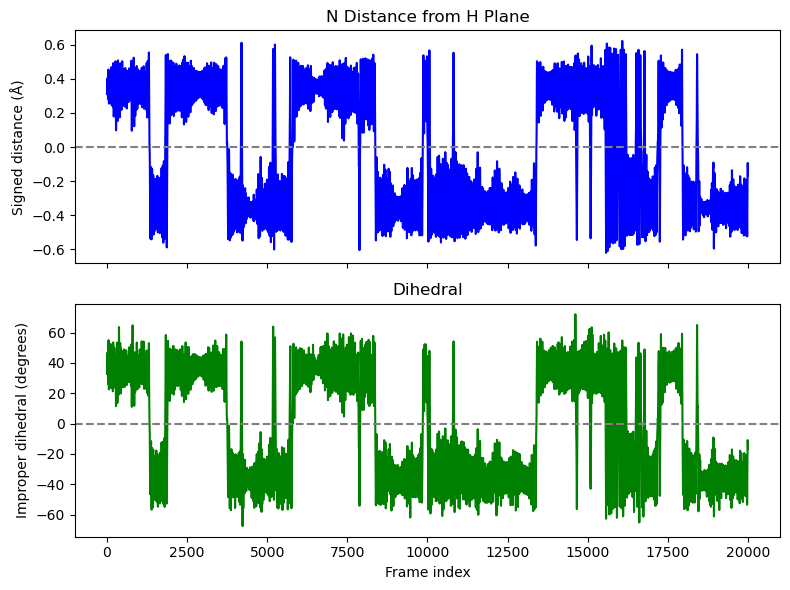

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read

# CV1: distance
def get_cv_distance(atoms):
    r_N = atoms.positions[0]
    r_H1, r_H2, r_H3 = atoms.positions[1:4]
    v1 = r_H2 - r_H1
    v2 = r_H3 - r_H1
    n = np.cross(v1, v2)
    n_hat = n / np.linalg.norm(n)
    d = np.dot(r_N - r_H1, n_hat)
    return d

# CV 2: dihedral
def get_cv_dihedral(atoms):
    N, H1, H2, H3 = atoms.positions[0], atoms.positions[1], atoms.positions[2], atoms.positions[3]

    # Cumbersome way, but is more alike to CV1 than .get_dihedral() function
    b1 = H2 - H1
    b2 = H3 - H2
    b3 = N  - H3
    n1 = np.cross(b1, b2)
    n2 = np.cross(b2, b3)
    n1 /= np.linalg.norm(n1)
    n2 /= np.linalg.norm(n2)
    b2n = b2 / np.linalg.norm(b2)
    angle = np.arctan2(np.dot(np.cross(n1, n2), b2n), np.dot(n1, n2))
    return angle

Temp = int(3000)
trajectory = read(f"./session6/nh3/md/{Temp}K/traj.xyz", index=":")

cv_distance = np.array([get_cv_distance(atoms) for atoms in trajectory])
cv_dihedral = np.array([get_cv_dihedral(atoms) for atoms in trajectory])*180/np.pi

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# Distance
axes[0].plot(cv_distance, color='blue', lw=1.5)
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].set_ylabel('Signed distance (Å)')
axes[0].set_title('N Distance from H Plane')

# Dihedral
axes[1].plot(cv_dihedral, color='green', lw=1.5)
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_ylabel('Improper dihedral (degrees)')
axes[1].set_xlabel('Frame index')
axes[1].set_title('Dihedral')

plt.tight_layout()
plt.show()


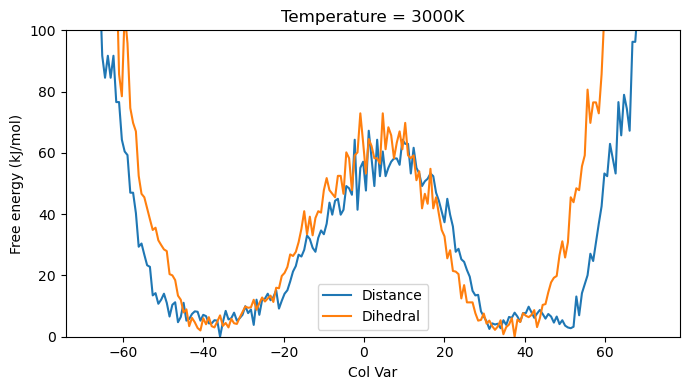

In [ ]:
# Temperature in Kelvin
kB = 0.0083145  # kJ/mol/K

nbins = 200
hist_distance, bin_edges = np.histogram(cv_distance, bins=nbins, density=True)
hist_dihedral, bin_edges = np.histogram(cv_dihedral, bins=nbins, density=True)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

F_distance = -kB * Temp * np.log(hist_distance+1e-12)
F_distance -= F_distance.min()  # set minimum to 0

F_dihedral = -kB * Temp * np.log(hist_dihedral+1e-12)
F_dihedral -= F_dihedral.min()  # set minimum to 0

plt.figure(figsize=(7,4))
plt.plot(bin_centers, F_distance,label="Distance")
plt.plot(bin_centers, F_dihedral,label="Dihedral")
plt.xlabel('Col Var')
plt.ylabel('Free energy (kJ/mol)')
plt.title(f"Temperature = {int(Temp)}K")
#plt.xlim(-60,60)
plt.ylim(0,100)
plt.legend()
plt.tight_layout()
plt.show()


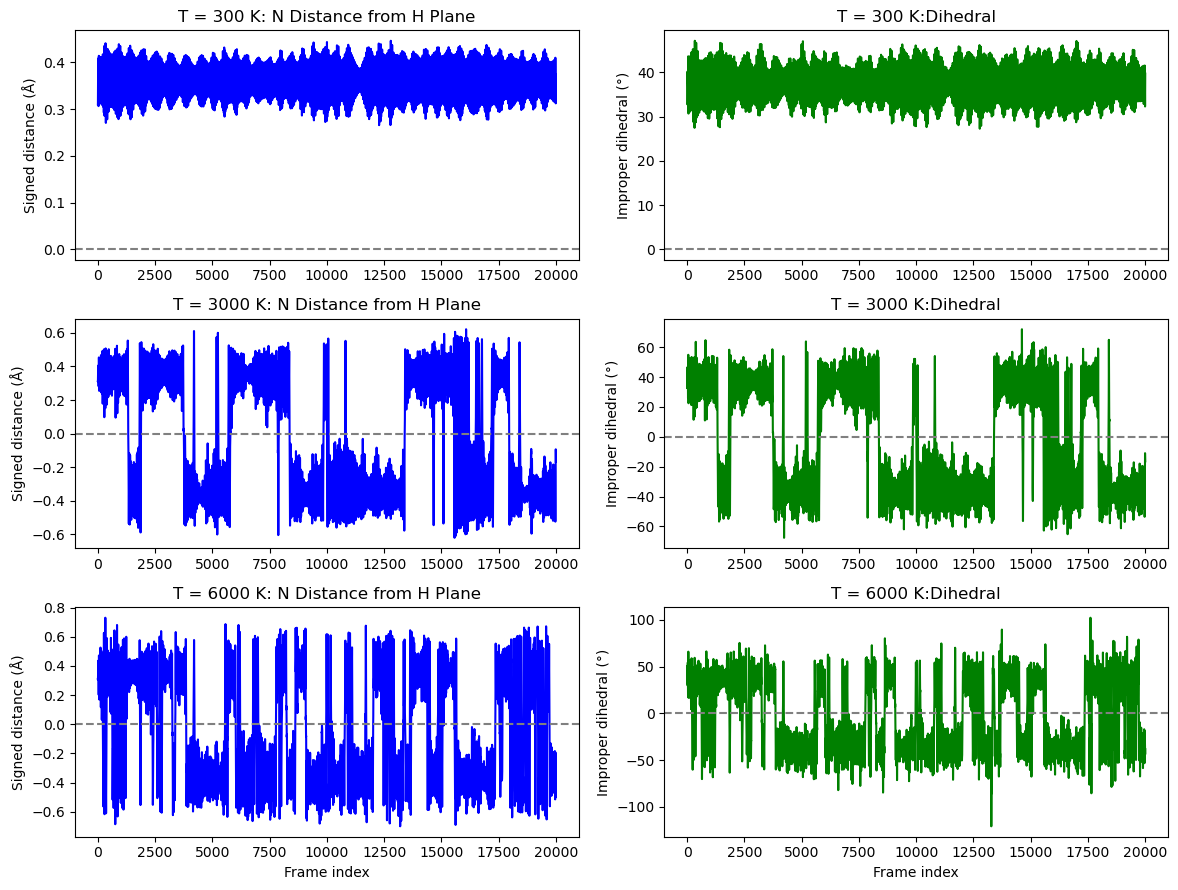

In [ ]:
temperatures = [300, 3000, 6000]

fig, axes = plt.subplots(len(temperatures), 2, figsize=(12, 9), sharex=False)

for i, Temp in enumerate(temperatures):
    traj = read(f"./session6/nh3/md/{Temp}K/traj.xyz", index=":")
    
    cv_dist = np.array([get_cv_distance(atoms) for atoms in traj])
    cv_dih = np.array([get_cv_dihedral(atoms) for atoms in traj])
    
    axes[i, 0].plot(cv_dist, color='blue', lw=1.5)
    axes[i, 0].axhline(0, color='gray', linestyle='--')
    axes[i, 0].set_ylabel('Signed distance (Å)')
    axes[i, 0].set_title(f'T = {Temp} K: N Distance from H Plane')
    
    axes[i, 1].plot(cv_dih, color='green', lw=1.5)
    axes[i, 1].axhline(0, color='gray', linestyle='--')
    axes[i, 1].set_ylabel('Improper dihedral (°)')
    axes[i, 1].set_title(f'T = {Temp} K:Dihedral')

for ax in axes[-1, :]:
    ax.set_xlabel('Frame index')

plt.tight_layout()
plt.show()


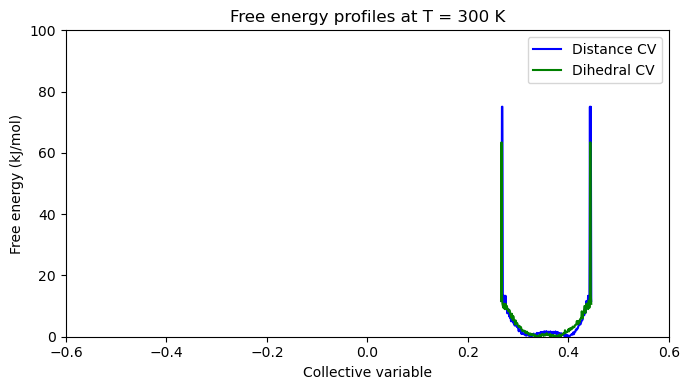

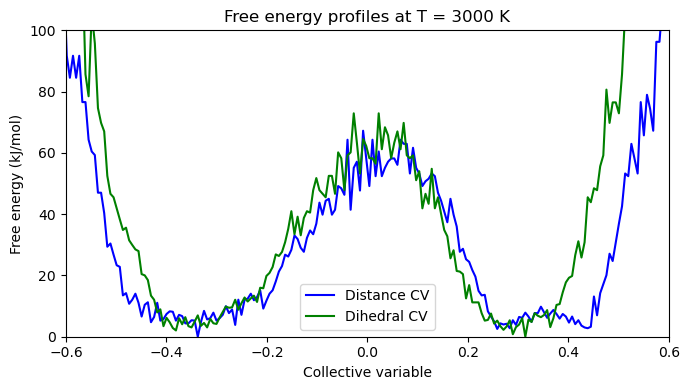

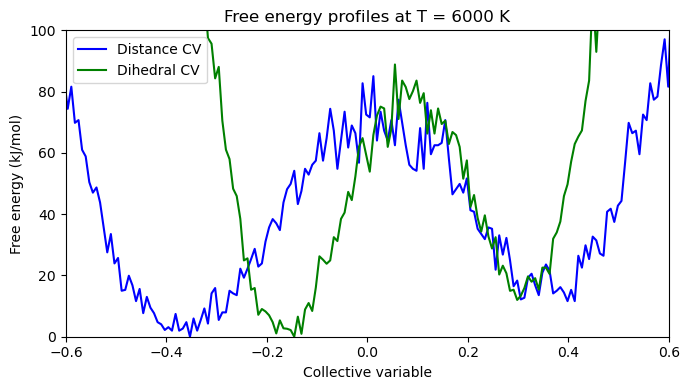

In [ ]:
kB = 0.0083145  # kJ/mol/K
nbins = 200
temperatures = [300, 3000, 6000]

for Temp in temperatures:
    traj = read(f"./session6/nh3/md/{Temp}K/traj.xyz", index=":")
    
    cv_distance = np.array([get_cv_distance(atoms) for atoms in traj])
    cv_dihedral = np.array([get_cv_dihedral(atoms) for atoms in traj])
    
    hist_dist, bin_edges = np.histogram(cv_distance, bins=nbins, density=True)
    hist_dih, _ = np.histogram(cv_dihedral, bins=nbins, density=True)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    
    F_distance = -kB * Temp * np.log(hist_dist + 1e-12)
    F_distance -= F_distance.min()
    
    F_dihedral = -kB * Temp * np.log(hist_dih + 1e-12)
    F_dihedral -= F_dihedral.min()
    
    plt.figure(figsize=(7,4))
    plt.plot(bin_centers, F_distance, label="Distance CV", color='blue')
    plt.plot(bin_centers, F_dihedral, label="Dihedral CV", color='green')
    plt.xlabel("Collective variable")
    plt.ylabel("Free energy (kJ/mol)")
    plt.title(f"Free energy profiles at T = {Temp} K")
    plt.ylim(0, 100)
    plt.xlim(-0.6,0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

## Exercise 2: Metadynamics

<div class="alert alert-block alert-warning">
<b>In short:</b> <br>
    1. Compute free energy profiles from the results of a metadynamics simulation. <br>
    2. Evaluate the simulation convergence.
</div>

The simulation results are available in `session6_input/nh3/metadynamics`. In the folder you may find:
<ul>
  <li>traj.xyz -> the trajectory xyz file</li>
  <li>out.ener -> file containing some simulation parameters (temperature, potential energy, etc.)</li>
  <li>colvar.dat -> collective variable time series, in radians</li>
  <li>HILLS -> file containing the parameters of the spawned hills, check its header to see which quantities are printed</li>
</ul>

In metadynamics, a series of gaussian-shaped hills is spawned every $n$ timesteps at the average collective variable value visited by the system in the previous $n$ steps. Given a collective variable $q$, we can call the hill center $q_0$. Moreover, the user can define a certain height $h$ and width $\sigma$ for the hills. The metadynamics free energy is then given by the sum of the spawned hills changed in sign, that is:
<center>
$F(q) = - \sum_i h_i \exp \left(- \frac{(q - q_{i,0})^2}{2 \sigma}\right)$
</center>
We used as collective variable the N-H-H-H dihedral angle to perform a metadynamics simulation at 300 K. A hill was spawned every 100 steps with a height of 0.5 kJ/mol and a width of 0.05 rad. We propagated the system for 40 ps with a timestep of 0.5 fs and saved the trajectory and CV value every two steps.

<div class="alert alert-block alert-success">
<b>Answer the following questions:</b> <br>   
<ol type='a'>
<li> Code a function that, given the HILLS file present in the results folder, allows you to compute the resulting free energy profile. </li>
<br>
<li> Compute the free energy profiles of the pyramidal inversion at 300 K. How can you estimate the convergence of a metadynamics simulation? </li>
</ol>
</div>

### Question 1

In [ ]:
def compute_metadynamics_FE(HILLS_file, q_grid=None):
    data = []
    with open(HILLS_file) as f:
        for line in f:
            if line.startswith('#'):
                continue
            fields = line.strip().split()
            if len(fields) == 0:
                continue
            data.append(fields)
    data = np.array(data, dtype=float)

    # Columns:  time, dihed, sigma_dihed, height, biasf
    q0 = data[:, 1]
    sigma = data[:, 2]
    h = data[:, 3]

    if q_grid is None:
        q_min = -90/180 * np.pi #q0.min() - 3.5*sigma.max()
        q_max = 90/180 * np.pi #q0.max() + 3.5*sigma.max()
        q_grid = np.linspace(q_min, q_max, 1000)

    F = np.zeros_like(q_grid)
    for i in range(len(q0)):
        F -= h[i] * np.exp(-0.5 * ((q_grid - q0[i]) / sigma[i])**2)

    F -= F.min()

    plt.figure()
    plt.plot(np.array(data[:,0])*1e-3, np.degrees(q0))
    plt.xlabel("simulation time (ps)")
    plt.ylabel("dihedral angle (degrees)")
    plt.show()

    return q_grid, F


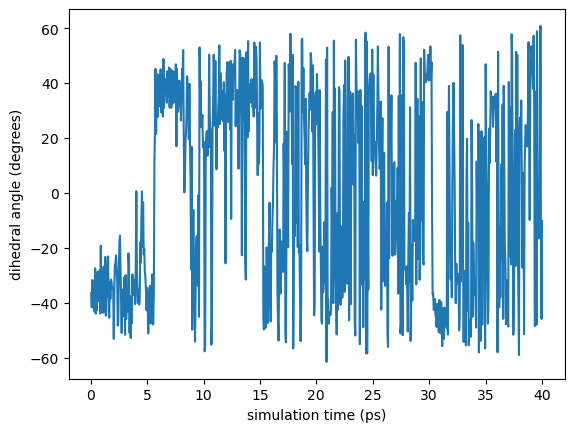

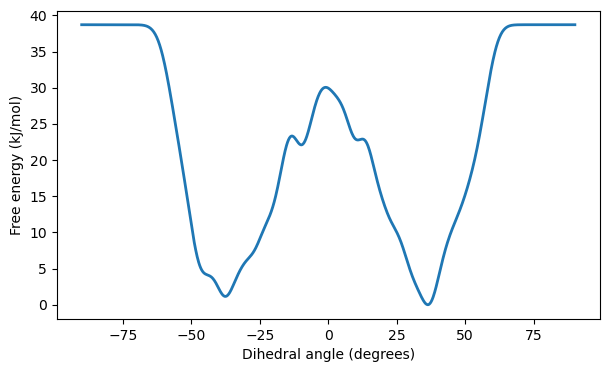

In [9]:
q_grid, F = compute_metadynamics_FE("./session6/nh3/metadynamics/HILLS")

plt.figure(figsize=(7,4))
plt.plot(q_grid*180/np.pi, F, lw=2)
plt.xlabel("Dihedral angle (degrees)")
plt.ylabel("Free energy (kJ/mol)")
plt.show()


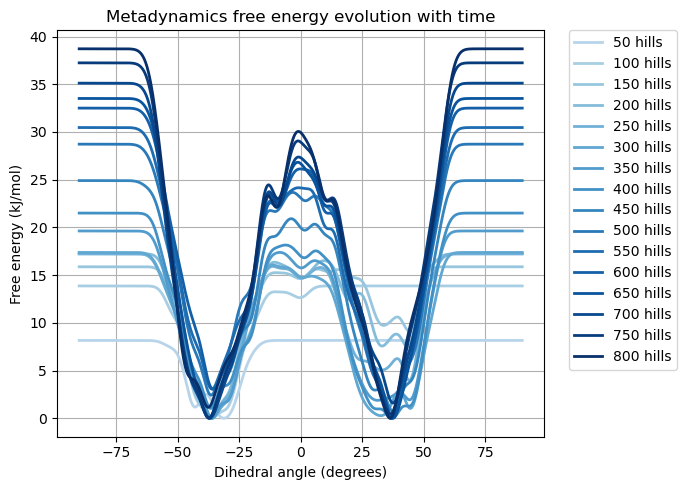

In [ ]:
def compute_metadynamics_FE_partial(HILLS_file, n_hills, q_grid=None):
    data = []
    with open(HILLS_file) as f:
        for line in f:
            if line.startswith('#'):
                continue
            fields = line.strip().split()
            if len(fields) == 0:
                continue
            data.append(fields)
    data = np.array(data, dtype=float)

    q0 = data[:n_hills, 1]      # hill centers
    sigma = data[:n_hills, 2]   # hill widths
    h = data[:n_hills, 3]       # hill heights

    if q_grid is None:
        q_min = -90/180 * np.pi #q0.min() - 3.5*sigma.max()
        q_max = 90/180 * np.pi #q0.max() + 3.5*sigma.max()
        q_grid = np.linspace(q_min, q_max, 1000)

    F = np.zeros_like(q_grid)
    for i in range(len(q0)):
        F -= h[i] * np.exp(-0.5 * ((q_grid - q0[i]) / sigma[i])**2)

    F -= F.min()
    return q_grid, F


HILLS_file = "./session6/nh3/metadynamics/HILLS"


with open(HILLS_file) as f:
    n_total = sum(1 for line in f if not line.startswith('#'))

n_snapshots = 16
hill_indices = np.linspace(50, n_total, n_snapshots, dtype=int)

fig, ax = plt.subplots(figsize=(7, 5)) 
colors = plt.cm.Blues(np.linspace(0.3, 1, len(hill_indices)))

for i, nh in enumerate(hill_indices):
    q_grid, F = compute_metadynamics_FE_partial(HILLS_file, n_hills=nh)
    ax.plot(np.degrees(q_grid), F, color=colors[i], lw=2, label=f"{nh} hills")

ax.set_xlabel("Dihedral angle (degrees)")
ax.set_ylabel("Free energy (kJ/mol)")
ax.set_title("Metadynamics free energy evolution with time")
ax.grid(True)

ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)

plt.tight_layout()
plt.show()


## Exercise 3: Umbrella sampling

<div class="alert alert-block alert-warning">
<b>In short:</b> <br>
    1. Compute free energy profiles from the results of an umbrella sampling simulation. <br>
    2. Compare the results with metadynamics.
</div>

The simulation results are available in `session6_input/nh3/umbrella_sampling`. A subdirectory is present for each temperature. In each subdirectory, you may find:
<ul>
  <li>traj_$i$.xyz -> the trajectory xyz file for the $i^{th}$ umbrella </li>
  <li>out_$i$.ener -> file containing some simulation parameters (temperature, potential energy, etc.) for the $i^{th}$ umbrella </li>
  <li>colvar_$i$.dat -> collective variable time series, in radians, for the $i^{th}$ umbrella </li>
  <li>wham_input.txt -> file containing a ordered list of umbrella centers and force constants (in radians and kJ/mol, respectively)</li>
</ul>

In umbrella sampling, a set of quadratic biasses (the umbrellas) is uniformly distributed along the CV range of interest. The bias of the $i^{th}$ umbrella is defined as:
$$
V_i(q) = \frac{1}{2} \kappa (q - q_{0,i})^2
$$
In which $\kappa$ is the umbrella force constant and $q_{0,i}$ its center. Provided that the CV probabilities in all umbrellas overlap sufficiently, the free energy profile can be computed using the weighted histogram analysis method (WHAM). For your convenience, a minimal implementation of WHAM is ready to be used in `session6_input/wham.py`. We performed for you three umbrella sampling simulations at 300, 500 and 700 K, using the same CV as in exercise 2. Each simulation consists of 30 umbrellas equally spaced between -1.0 and 1.0 rad ($\pm$ 57.3 deg) and propagated for 20 ps. The umbrella centers and force constants are listed in the `wham_input.txt` file.

<div class="alert alert-block alert-success">
<b>Answer the following questions:</b> <br>   
<ol type='a'>
<li> Compute the free energy profile of the ammonia pyramidal inversion at 300, 500, and 700 K. How do the profiles look like? Does entropy play an important role in this reaction? </li>
<br>
<li> Are the different umbrellas sufficiently overlapping in CV space? </li>
<br>
<li> How does the umbrella sampling free energy compare with the metadynamics one? </li>
</ol>
</div>

<div class="alert alert-block alert-info">
<b>Tip - using the WHAM script</b> <br>

Hereafter is a minimum example on how you could use the provide WHAM script.
    
```python
from session6_input.wham import wham

bins = None # FIX ME! Define a set of bins to perform the WHAM analysis
temp = 300.0

# load umbrella centers and force constants
centers, kappas = [], []
with open("session6_input/nh3/umbrella_sampling/{}K/wham_input.txt".format(int(temp)), "r") as f:
    for line in f:
        ###
        # FIX ME! Extract the necessary values from the wham input file
        ###
        centers.append(center)
        kappas.append(kappa)

# load the collective variable time series
eq_time = 0 # discard a certain equilibration time, if you wish
cv_timeseries_list = [np.loadtxt(path_us / f"colvar_{i}.dat")[eq_time:,1] for i in range(30)]

# compute the free energy via WHAM
bin_centers, free_energy, _ = wham(cv_timeseries_list, centers, kappas, temp, bins)

# further analysis ...
```
</div>

### Question 1

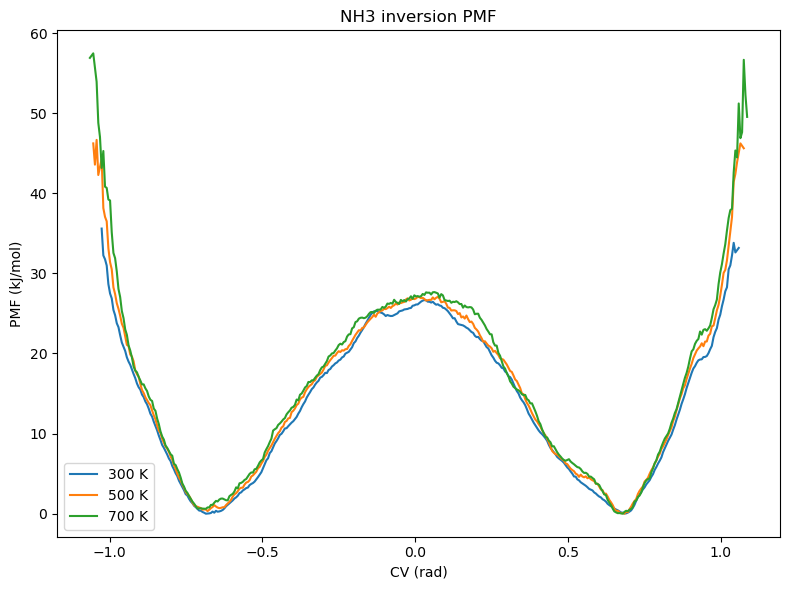

In [ ]:
from session6.wham import wham
import os

base = os.path.join("session6", "nh3", "umbrella_sampling")
temps = [300, 500, 700]
n_windows = 30

results = []
plt.figure(figsize=(8,6))

for T in temps:
    folder = os.path.join(base, f"{int(T)}K")

    wpath = os.path.join(folder, "wham_input.txt")
    arr = np.loadtxt(wpath)
    if arr.ndim == 1:
        arr = arr.reshape(1, -1)
    centers = arr[:,0].tolist()
    kappas = arr[:,1].tolist()

    cv_list = []
    for i in range(n_windows):
        p = os.path.join(folder, f"colvar_{i}.dat")
        data = np.loadtxt(p)
        cv_list.append(data[:,1])  # second column = cv in radians

    bin_edges = np.linspace(-1.1, 1.1, 401)
    bin_centers, pmf, F_i_energy = wham(cv_list, centers, kappas, float(T), bin_edges)

    x = bin_centers
    y = pmf

    left_min = np.min(y[x < -0.1])
    right_min = np.min(y[x >  0.1])
    center_max = np.max(y[(x >= -0.2) & (x <= 0.2)])
    avg_min = (left_min + right_min) / 2
    barrier = center_max - avg_min

    results.append((T, left_min, right_min, center_max, avg_min, barrier))
    plt.plot(x, y, label=f"{T} K")
plt.xlabel("CV (rad)")
plt.ylabel("PMF (kJ/mol)")
plt.legend()
plt.title("NH3 inversion PMF")
plt.tight_layout()
plt.show()


In [ ]:
print("T (K)   left_min   right_min  center_max   avg_min    barrier (kJ/mol)")
for r in results:
    print("{:6.0f} {:10.4f} {:10.4f} {:10.4f} {:10.4f} {:10.4f}".format(*r))

Ts = np.array([r[0] for r in results])
barriers = np.array([r[5] for r in results])
coeffs = np.polyfit(Ts, barriers, 1)  # barrier = a + b*T
slope, intercept = coeffs[0], coeffs[1]
delta_S_kJ_per_molK = -slope
print("\n--------------------------------------------------------------------\n")
print(" ΔS = {:.4f} J/mol/K".format(delta_S_kJ_per_molK*1000))

T (K)   left_min   right_min  center_max   avg_min    barrier (kJ/mol)
   300     0.0000     0.0200    26.6650     0.0100    26.6550
   500     0.3267     0.0000    27.0741     0.1633    26.9108
   700     0.6092     0.0000    27.6609     0.3046    27.3564

--------------------------------------------------------------------

 ΔS = -1.7534 J/mol/K


### Question 2

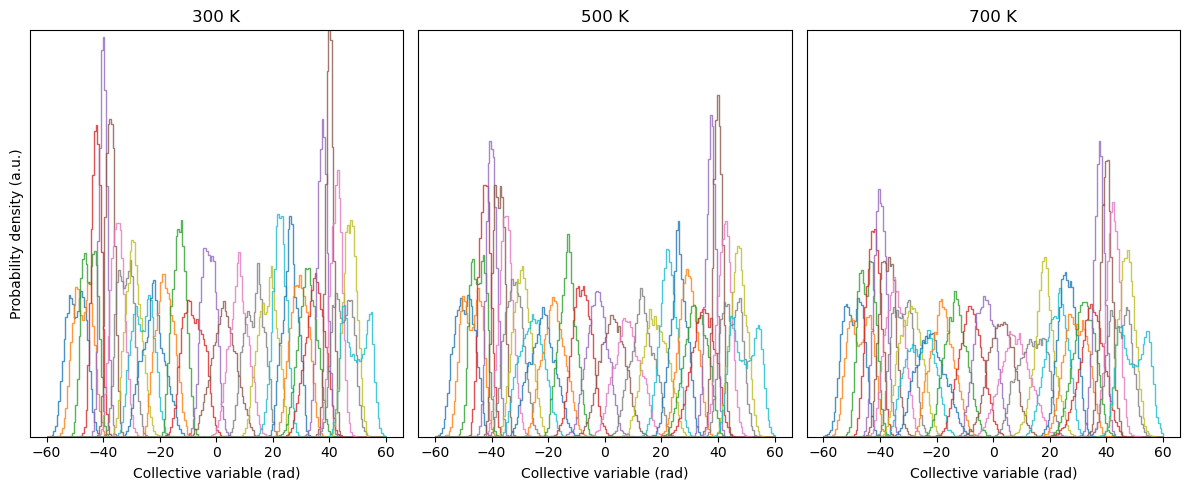

In [ ]:
temperatures = [300, 500, 700]
base_path = "./session6/nh3/umbrella_sampling"
cv_range = (-60, 60)

fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharex=True)

for ax, temp in zip(axes, temperatures):
    folder = f"{base_path}/{temp}K"

    wham_input = np.loadtxt(f"{folder}/wham_input.txt")

    for i in range(len(wham_input)):
        data = np.loadtxt(f"{folder}/colvar_{i}.dat")
        cv = np.degrees(data[:, 1])
        ax.hist(cv, bins=200, range=cv_range, density=True, 
                histtype='step', alpha=0.8)

    ax.set_title(f"{temp} K")
    ax.set_xlabel("Collective variable (rad)")
    ax.set_ylim(0,0.3)
    ax.set_yticks([])

axes[0].set_ylabel("Probability density (a.u.)")

plt.tight_layout()
plt.show()

### Question 3

<Figure size 800x600 with 0 Axes>

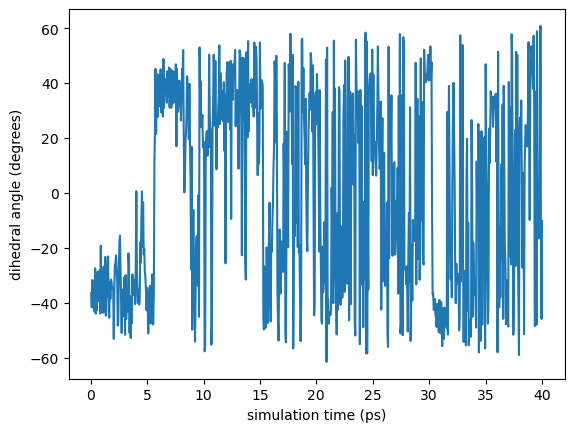

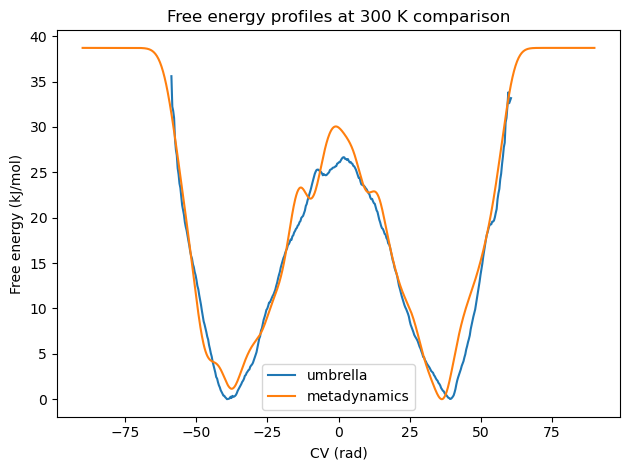

In [ ]:
# at this point i just copied code from earlier questions
T = 300

# Umbrella
n_windows = 30

plt.figure(figsize=(8,6))

folder = os.path.join("session6", "nh3", "umbrella_sampling", f"{int(T)}K")

wpath = os.path.join(folder, "wham_input.txt")
arr = np.loadtxt(wpath)
if arr.ndim == 1:
    arr = arr.reshape(1, -1)
centers = arr[:,0].tolist()
kappas = arr[:,1].tolist()

cv_list = []
for i in range(n_windows):
    p = os.path.join(folder, f"colvar_{i}.dat")
    data = np.loadtxt(p)
    cv_list.append(data[:,1])  # second column = cv in radians

bin_edges = np.linspace(-1.1, 1.1, 401)
bin_centers, pmf, F_i_energy = wham(cv_list, centers, kappas, float(T), bin_edges)

x = bin_centers
y = pmf


# metadynamics
q_grid, F = compute_metadynamics_FE("./session6/nh3/metadynamics/HILLS")

plt.plot(np.degrees(x), y, label="umbrella")
plt.plot(q_grid*180/np.pi, F, label="metadynamics")
plt.xlabel("CV (rad)")
plt.ylabel("Free energy (kJ/mol)")
plt.legend()
plt.title(f"Free energy profiles at {T} K comparison")
plt.tight_layout()
plt.show()


## Exercise 4: The breathing of MIL-53(Al)

<div class="alert alert-block alert-warning">
<b>In short:</b> <br>
    1. Compute the free energy profile of the open-pore to close-pore transition of MIL-53(Al). <br>
    2. Evaluate the impact of choosing different collective variables.
</div>

MIL-53(Al) is a metal-organic-framework with a particular wine-rack topology. It is composed by aluminum hydroxyde chains interconnected by terephtalic acid ligands. This allows the MOF to "breath", meaning that it collapses from an open pore (OP) to a close pore (CP) phase upon temperature/pressure changes and/or adsorption of guests molecules.

<figure>
<center><img src="https://upload.wikimedia.org/wikipedia/commons/e/e4/MIL-53ht.png" width="500"></center>
<center><figcaption>Figure 2: The topology of MIL-53-Al.</figcaption></center>
</figure>

We have performed two umbrella sampling simulations at 300 K and 1 atm to investigate the breathing behavior of MIL-53(Al) using an accurate machine learning potential (more on this later in the course) to estimate the potential energy surface. We chose two separate collective variables to describe the CP to OP transition: the unit cell volume and the length of the z cell vector.

The files are stored in `session6_input/mil-53/umbrella_sampling`. One subdirectory is present for each of the two collective variables. In `session6_input/mil-53` you may also find an xyz file with a typical snapshot of the OP and CP structures (sharing the whole trajectory would have required too much memory).

<div class="alert alert-block alert-success">
<b>Answer the following questions:</b> <br>   
<ol type='a'>
<li> Compute the free energy profiles for the OP-CP transition in MIL-53(Al) with the two different collective variables. Which phase is the most stable at the considered conditions? </li>
<br>
<li> Are the two collective variables producing comparable results? If not, why? </li>
<br>
<li> Compute the free energy difference between the two phases rigorously. Does this improve the agreement between the two collective variables? </li>
</ol>
</div>

### Question 1 - 2

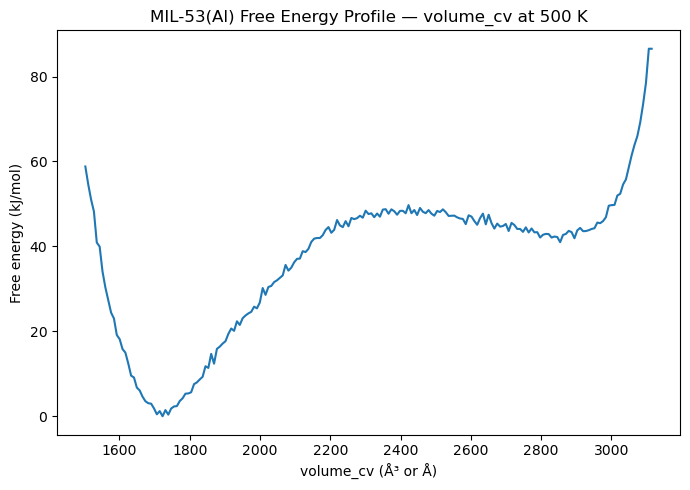

Most stable phase for CV 'volume_cv' at 500 K → CV ≈ 1722.731


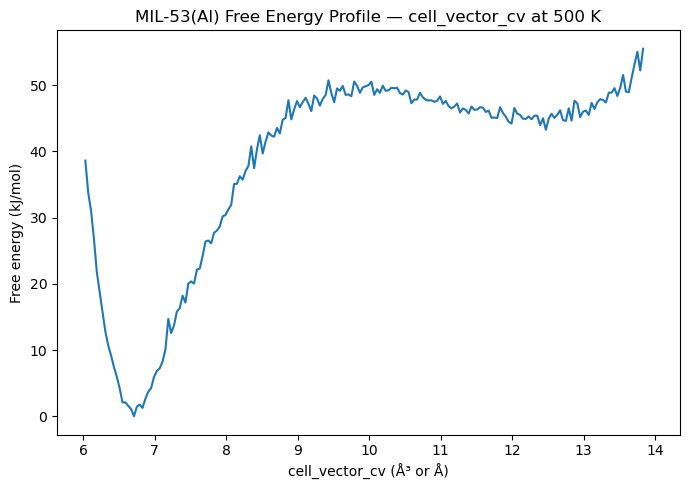

Most stable phase for CV 'cell_vector_cv' at 500 K → CV ≈ 6.710


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from session6.wham import wham


temp = 500.0 
cv_types = ["volume_cv", "cell_vector_cv"]
eq_time = 0 # frames to skip for equilibration
n_bins = 200 # number of bins for WHAM


results = {}

for idx, cv_type in enumerate(cv_types):
    folder = Path(f"./session6/mil-53/umbrella_sampling/{cv_type}")

    # umbrella centers and force constants
    centers, kappas = np.loadtxt(folder / "wham_input.txt", unpack=True)
    
    # CV time series for all umbrella windows
    cv_series = []
    for i in range(len(centers)):
        data = np.loadtxt(folder / f"colvar_{i}.dat")
        if data.ndim == 1:
            cv = data[eq_time:]
        else:
            cv = data[eq_time:, 1]
        cv_series.append(cv)
    
    # bins from overall sampled CV range
    cv_min = min(np.min(cv) for cv in cv_series)
    cv_max = max(np.max(cv) for cv in cv_series)
    bin_edges = np.linspace(cv_min, cv_max, n_bins)
    
    bin_centers, pmf, _ = wham(cv_series, centers, kappas, temp, bin_edges)
    pmf -= np.min(pmf)
    results[cv_type] = (bin_centers, pmf)

    plt.figure(figsize=(7,5))
    plt.plot(bin_centers,pmf,color='C0')
    plt.xlabel(f"{cv_type} (Å³ or Å)")
    plt.ylabel("Free energy (kJ/mol)")
    plt.title(f"MIL-53(Al) Free Energy Profile — {cv_type} at {temp:.0f} K")
    plt.tight_layout()
    plt.show()
    
    # Identify most stable phase
    min_idx = np.argmin(pmf)
    print(f"Most stable phase for CV '{cv_type}' at {temp:.0f} K → CV ≈ {bin_centers[min_idx]:.3f}")

### Question 3

<div class="alert alert-block alert-info">
<b>Tip - computing rigorous free energy differences</b> <br>

The free energy difference between two states $\Delta F = F_\mathcal{A} - F_\mathcal{B}$, separated by a transition state located at a certain collective variable value $q^\ddagger$, can be computed by integrating the CV-dependent free energy $F(q)$ over the CV range corresponding to each of the states. If we assume that $\mathcal{A}$ extends from $-\infty$ to $q^\ddagger$ and $\mathcal{B}$ from $q^\ddagger$ to $+\infty$ we have that:

$$
F_\mathcal{A} = - k_\mathrm{B}T \ln \left( \int_{-\infty}^{q^\ddagger} \exp \left( - \frac{F(q)}{k_\mathrm{B}T} \right) \mathrm{d}q \right)
$$

and

$$
F_\mathcal{B} = - k_\mathrm{B}T \ln \left( \int_{q^\ddagger}^{+\infty} \exp \left( - \frac{F(q)}{k_\mathrm{B}T} \right) \mathrm{d}q \right)
$$

<b>Note:</b> if $q$ has a unit (as in the case of volume), than the formulas above are not rigorously correct as we would take the logarithm of a quantity with a unit. However, you could imagine to divide the integral by an arbitrary value $q_0$ to remove the unit dependence, which would then cancel out when you compute the actual free energy difference between the two states.
</div>

In [ ]:
# I used a filter to smoothen the signal a little (and suppress noise influence)

from scipy.signal import savgol_filter

temp = 500.0 
kB = 0.0083144621
cv_types = ["volume_cv", "cell_vector_cv"]
n_bins = 200
smooth_window = 11 # odd integer for Savitzky–Golay
poly_order = 3
neighbor_range = 14 # number of points on each side to check for extrema

def find_local_extrema(y, neighbor_range=5):
    minima = []
    maxima = []
    for i in range(neighbor_range, len(y) - neighbor_range):
        window = y[i - neighbor_range:i + neighbor_range + 1]
        center = y[i]
        if center == np.min(window):
            minima.append(i)
        elif center == np.max(window):
            maxima.append(i)
    return np.array(minima), np.array(maxima)

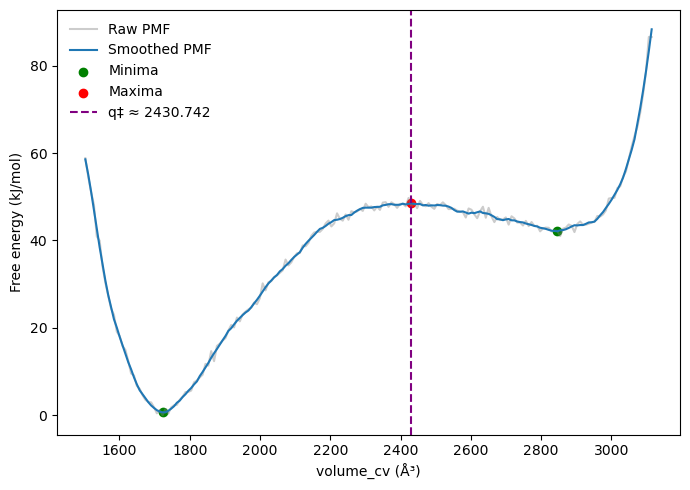

Integration: ΔF (CP → OP) = -37.35 kJ/mol at 500 K
Energy profile: ΔF (CP → OP) = -41.42 kJ/mol at 500 K


In [ ]:
# First for volume
cv_type = cv_types[0]

folder = Path(f"./session6/mil-53/umbrella_sampling/{cv_type}")
centers, kappas = np.loadtxt(folder / "wham_input.txt", unpack=True)

cv_series = []
for i in range(len(centers)):
    data = np.loadtxt(folder / f"colvar_{i}.dat")
    cv_series.append(data[:, 1] if data.ndim > 1 else data)

cv_min = min(np.min(cv) for cv in cv_series)
cv_max = max(np.max(cv) for cv in cv_series)
bin_edges = np.linspace(cv_min, cv_max, n_bins)

bin_centers, pmf, _ = wham(cv_series, centers, kappas, temp, bin_edges)
pmf -= np.nanmin(pmf)

pmf_smooth = savgol_filter(pmf, smooth_window, poly_order, mode="interp")

minima, maxima = find_local_extrema(pmf_smooth, neighbor_range=neighbor_range)

# Get free energy from profile
delta_F_profile = pmf_smooth[minima[0]] - pmf_smooth[minima[1]]

# transition state (largest maximum between first two minima)
if len(minima) >= 2 and len(maxima) > 0:
    # choose maximum between first two minima
    left_min, right_min = minima[0], minima[1]
    ts_candidates = [m for m in maxima if left_min < m < right_min]
    if ts_candidates:
        ts_idx = ts_candidates[np.argmax(pmf_smooth[ts_candidates])]
    else:
        ts_idx = maxima[np.argmax(pmf_smooth[maxima])]
    q_ts = bin_centers[ts_idx]
else:
    q_ts = np.mean(bin_centers)

# Integrate to get F_A and F_B
exp_factor = np.exp(-pmf_smooth / (kB * temp))
mask_A = bin_centers <= q_ts
mask_B = bin_centers > q_ts

Z_A = np.trapz(exp_factor[mask_A], bin_centers[mask_A])
Z_B = np.trapz(exp_factor[mask_B], bin_centers[mask_B])
F_A = -kB * temp * np.log(Z_A)
F_B = -kB * temp * np.log(Z_B)
delta_F = F_A - F_B

plt.figure(figsize=(7,5))
plt.plot(bin_centers, pmf, 'gray', alpha=0.4, label="Raw PMF")
plt.plot(bin_centers, pmf_smooth, 'C0', label="Smoothed PMF")
plt.scatter(bin_centers[minima], pmf_smooth[minima], color='green', label="Minima")
plt.scatter(bin_centers[maxima], pmf_smooth[maxima], color='red', label="Maxima")
plt.axvline(q_ts, color='purple', linestyle='--', label=f"q‡ ≈ {q_ts:.3f}")
plt.xlabel(f"{cv_type} (Å³)")
plt.ylabel("Free energy (kJ/mol)")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"Integration: ΔF (CP → OP) = {delta_F:.2f} kJ/mol at {temp:.0f} K")
print(f"Energy profile: ΔF (CP → OP) = {delta_F_profile:.2f} kJ/mol at {temp:.0f} K")

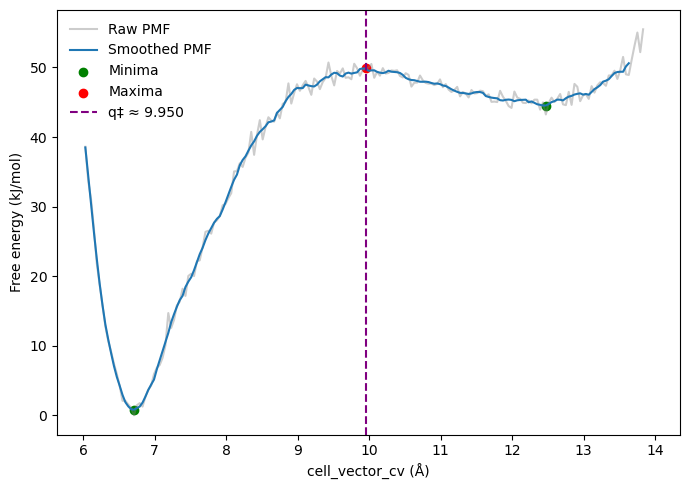

Integration: ΔF (CP → OP) = -6.33 kJ/mol at 500 K
Energy profile: ΔF (CP → OP) = -43.72 kJ/mol at 500 K


In [ ]:
# Now for cell length
cv_type = cv_types[1]

folder = Path(f"./session6/mil-53/umbrella_sampling/{cv_type}")
centers, kappas = np.loadtxt(folder / "wham_input.txt", unpack=True)

cv_series = []
for i in range(len(centers)):
    data = np.loadtxt(folder / f"colvar_{i}.dat")
    cv_series.append(data[:, 1] if data.ndim > 1 else data)

cv_min = min(np.min(cv) for cv in cv_series)
cv_max = max(np.max(cv) for cv in cv_series)
bin_edges = np.linspace(cv_min, cv_max, n_bins)

bin_centers, pmf, _ = wham(cv_series, centers, kappas, temp, bin_edges)
pmf -= np.nanmin(pmf)

pmf_smooth = savgol_filter(pmf, smooth_window, poly_order, mode="interp")

minima, maxima = find_local_extrema(pmf_smooth, neighbor_range=neighbor_range)

# Get free energy from profile
delta_F_profile = pmf_smooth[minima[0]] - pmf_smooth[minima[1]]

# Identify transition state
if len(minima) >= 2 and len(maxima) > 0:
    # choose maximum between first two minima
    left_min, right_min = minima[0], minima[1]
    ts_candidates = [m for m in maxima if left_min < m < right_min]
    if ts_candidates:
        ts_idx = ts_candidates[np.argmax(pmf_smooth[ts_candidates])]
    else:
        ts_idx = maxima[np.argmax(pmf_smooth[maxima])]
    q_ts = bin_centers[ts_idx] 
else:
    q_ts = np.mean(bin_centers)

# Integrate to get F_A and F_B
exp_factor = np.exp(-pmf_smooth / (kB * temp))
mask_A = bin_centers <= q_ts
mask_B = bin_centers > q_ts

Z_A = np.trapz(exp_factor[mask_A], bin_centers[mask_A])
Z_B = np.trapz(exp_factor[mask_B], bin_centers[mask_B])
F_A = -kB * temp * np.log(Z_A)
F_B = -kB * temp * np.log(Z_B)
delta_F = F_A - F_B

plt.figure(figsize=(7,5))
plt.plot(bin_centers, pmf, 'gray', alpha=0.4, label="Raw PMF")
plt.plot(bin_centers, pmf_smooth, 'C0', label="Smoothed PMF")
plt.scatter(bin_centers[minima], pmf_smooth[minima], color='green', label="Minima")
plt.scatter(bin_centers[maxima], pmf_smooth[maxima], color='red', label="Maxima")
plt.axvline(q_ts, color='purple', linestyle='--', label=f"q‡ ≈ {q_ts:.3f}")
plt.xlabel(f"{cv_type} (Å)")
plt.ylabel("Free energy (kJ/mol)")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"Integration: ΔF (CP → OP) = {delta_F:.2f} kJ/mol at {temp:.0f} K")
print(f"Energy profile: ΔF (CP → OP) = {delta_F_profile:.2f} kJ/mol at {temp:.0f} K")